#### Import all necessary Python libraries:
- pandas: for data manipulation and analysis
- scikit-learn: for data splitting, encoding, model building, and evaluation
- seaborn and matplotlib: for data visualization
- VarianceThreshold: for feature selection (though not used later in this notebook)


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

#### Load the quote data from 'quotes_customer_tier.csv' into a pandas DataFrame.


In [3]:
quote_df=pd.read_csv('../Dataset/quotes_customer_tier.csv')

C:\Users\ruthe\AppData\Local\Temp\ipykernel_3684\1079151308.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  quote_df=pd.read_csv('../Dataset/quotes_customer_tier.csv')


#### Drop unnecessary columns from the quote DataFrame to simplify the dataset for analysis.


In [4]:
quote_df = quote_df.drop(columns=['QuoteID', 'QuoteVersion', 'SalesPersonName', 'CustomerName', 'BranchName', 'Ship2City', 'Ship2State'])

#### Display the cleaned quote DataFrame to review its structure and data.


In [5]:
quote_df

,QuoteDate,ExpirationDate,SalesPersonID,CustomerID,ProductID,ProductGroupID,QuoteQty,UnitPrice,UOM,UnitSize,QuoteStatus,ConvertedToOrderNumber,ConversionDate,CustomerTier
0,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2005075.0,2025-01-08,4.320718e+06
1,2024-12-23,2025-01-17,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2007359.0,2025-01-20,4.320718e+06
2,2024-12-31,2025-01-14,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2007636.0,2025-01-21,4.320718e+06
3,2024-12-22,2024-12-27,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,48.000000,15.837708,EA,1.0,Won,2005075.0,2025-01-08,4.320718e+06
4,2024-12-17,2025-01-06,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,12.000000,15.837500,EA,1.0,Won,2006601.0,2025-01-15,4.320718e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2254813,2024-08-13,2024-09-29,SREP2,CUST2,MYG-205-YL6,PROD.Group14,0.953965,1.058656,EA,1.0,Lost,NaN,NaN,4.320718e+06
2254814,2024-10-08,2024-10-15,SREP5,CUST36,QZJ-829-XE3,PROD.Group3,953.288057,0.240658,EA,1.0,Lost,NaN,NaN,4.320718e+06
2254815,2024-10-07,2024-10-14,SREP6,CUST27,HFI-965-OK7,PROD.Group31,0.908320,37.743813,EA,1.0,Lost,NaN,NaN,4.320718e+06
2254816,2024-09-07,2024-08-31,SREP2,CUST2,CWL-587-JF4,PROD.Group3,1.009181,90.602969,EA,1.0,Lost,NaN,NaN,4.320718e+06


#### Perform exploratory counts to find the number of unique values in important fields:
- ProductID
- SalesPersonID
- CustomerID
- ProductGroupID
- UOM
- ConvertedToOrderNumber


In [6]:
# Count the number of unique ProductIDs
unique_product_count = quote_df['ProductID'].nunique()

print(f"The 'ProductID' column has {unique_product_count} unique values.")

The 'ProductID' column has 37935 unique values.


In [7]:
# Count the number of unique SalesPersonID
unique_count = quote_df['SalesPersonID'].nunique()

print(f"The 'SalesPersonID' column has {unique_count} unique values.")

The 'SalesPersonID' column has 21 unique values.


In [8]:
# Count the number of unique CustomerID
unique_count = quote_df['CustomerID'].nunique()

print(f"The 'CustomerID' column has {unique_count} unique values.")

The 'CustomerID' column has 1050 unique values.


In [9]:
# Count the number of unique ProductGroupID
unique_count = quote_df['ProductGroupID'].nunique()

print(f"The 'ProductGroupID' column has {unique_count} unique values.")

The 'ProductGroupID' column has 72 unique values.


In [10]:
# Count the number of unique UOM
unique_count = quote_df['UOM'].nunique()

print(f"The 'UOM' column has {unique_count} unique values.")

The 'UOM' column has 54 unique values.


In [11]:
# Count the number of unique ConvertedToOrderNumber
unique_count = quote_df['ConvertedToOrderNumber'].nunique()

print(f"The 'ConvertedToOrderNumber' column has {unique_count} unique values.")

The 'ConvertedToOrderNumber' column has 224960 unique values.


In [13]:
sales_df=pd.read_csv('../Dataset/OriginalData/Intuilize_MNSU_ACME_SalesData.csv')

#### Count the number of quotes with 'Won', 'Revised', and 'Lost' statuses.


In [14]:
won_lost_counts = quote_df['QuoteStatus'].value_counts().loc[['Won', 'Revised','Lost']]
print(won_lost_counts)

QuoteStatus
Won        1214881
Revised     493241
Lost        546696
Name: count, dtype: int64


#### Count the number of unique OrderNumbers in the sales dataset.


In [15]:
# Count the number of unique OrderNumber
unique_count = sales_df['OrderNumber'].nunique()

print(f"The 'OrderNumber' column has {unique_count} unique values.")

The 'OrderNumber' column has 224960 unique values.


#### Display the loaded sales DataFrame to inspect its contents.


In [16]:
sales_df

,BranchName,Ship2City,Ship2State,OrderNumber,InvoiceNumber,LineNumber,OrderDate,SalesDate,SalesPersonID,SalesPersonName,...,ProductGroupID,CustomerID,CustomerName,ExtPrice,ExtCost,SalesQty,UnitPrice,UnitCost,UOM,UnitSize
0,JOHNHAVEN BRANCH,MUSCATINE,IA,2005075,2003955,1.0,2025-01-08,2025-01-08,SREP1,MELISSA MACIAS,...,PROD.Group1,CUST1,"BROWN, BURKE AND SMITH LLC",906.67,672.38,24,37.777917,28.015833,EA,1.0
1,JOHNHAVEN BRANCH,MUSCATINE,IA,2007359,2006361,1.0,2025-01-20,2025-01-20,SREP1,MELISSA MACIAS,...,PROD.Group1,CUST1,"BROWN, BURKE AND SMITH LLC",906.67,672.38,24,37.777917,28.015833,EA,1.0
2,JOHNHAVEN BRANCH,MUSCATINE,IA,2007636,2006694,1.0,2025-01-21,2025-01-21,SREP1,MELISSA MACIAS,...,PROD.Group1,CUST1,"BROWN, BURKE AND SMITH LLC",906.67,672.38,24,37.777917,28.015833,EA,1.0
3,JOHNHAVEN BRANCH,MUSCATINE,IA,2005075,2003955,3.0,2025-01-08,2025-01-08,SREP1,MELISSA MACIAS,...,PROD.Group2,CUST1,"BROWN, BURKE AND SMITH LLC",760.21,562.56,48,15.837708,11.720000,EA,1.0
4,JOHNHAVEN BRANCH,MUSCATINE,IA,2006601,2005549,2.0,2025-01-15,2025-01-15,SREP1,MELISSA MACIAS,...,PROD.Group2,CUST1,"BROWN, BURKE AND SMITH LLC",190.05,140.64,12,15.837500,11.720000,EA,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214876,NORTH SARAHTON BRANCH,CEDARTOWN,GA,1979110,1976544,10.0,2024-09-11,2024-09-11,SREP8,YESENIA WILLIAMS,...,PROD.Group12,CUST14,"OWEN, WATKINS AND TOMLINSON INC",153.20,71.43,4000,0.038300,0.017857,FT,1.0
1214877,JOHNHAVEN BRANCH,MUSCATINE,IA,1979253,1976741,13.0,2024-09-11,2024-09-11,SREP5,CHRISTOPHER CLEMENTS,...,PROD.Group12,CUST8,ROBERTS LLC GROUP,153.20,69.35,4000,0.038300,0.017337,FT,1.0
1214878,JOHNHAVEN BRANCH,MUSCATINE,IA,1983280,1981052,1.0,2024-09-26,2024-09-27,SREP5,CHRISTOPHER CLEMENTS,...,PROD.Group12,CUST128,TORRES-DAVIS LTD,306.40,138.70,8000,0.038300,0.017337,FT,1.0
1214879,NORTH SARAHTON BRANCH,CEDARTOWN,GA,1983579,1981335,8.0,2024-09-30,2024-09-30,SREP8,YESENIA WILLIAMS,...,PROD.Group12,CUST14,"OWEN, WATKINS AND TOMLINSON INC",153.20,71.43,4000,0.038300,0.017857,FT,1.0


#### Split quotes into separate DataFrames based on 'QuoteStatus' and remove these records from the main quote DataFrame.
- lost_df: status 'Lost'
- revised_df: status 'Revised'
- won_df: status 'Won'


In [17]:
# Create lost_df with only 'Lost' rows
lost_df = quote_df[quote_df['QuoteStatus'] == 'Lost'].copy()
revised_df = quote_df[quote_df['QuoteStatus'] == 'Revised'].copy()
won_df = quote_df[quote_df['QuoteStatus'] == 'Won'].copy()
# Remove 'Lost' rows from quote_df (keeping the rest)
quote_df = quote_df[quote_df['QuoteStatus'] != 'Lost'].copy()
quote_df = quote_df[quote_df['QuoteStatus'] != 'Revised'].copy()
quote_df = quote_df[quote_df['QuoteStatus'] != 'Won'].copy()

#### Rename 'ConvertedToOrderNumber' to 'OrderNumber' in won and lost DataFrames.
#### Remove the 'ConversionDate' column since it's no longer needed.


In [18]:
#changed the convertedToOrderrNumber to OrderNumber
won_df = won_df.rename(columns={'ConvertedToOrderNumber': 'OrderNumber'})
lost_df = lost_df.rename(columns={'ConvertedToOrderNumber': 'OrderNumber'})
#drop ConversionDate feature
won_df = won_df.drop('ConversionDate', axis=1)  # axis=1 specifies column drop
lost_df = lost_df.drop('ConversionDate', axis=1)  # axis=1 specifies column drop

#### Merge 'won_df' with 'sales_df' on 'OrderNumber' to enrich won quotes with sales details.
#### Perform a left join to retain all won quotes even if no sales record exists.


In [19]:
# Merge quote_df with sales_df using the order number as the key
combined_df = won_df.merge(
    sales_df,
    left_on='OrderNumber',  # From won_df
    right_on='OrderNumber',            # From sales_df
    how='left'                         # Keeps all quotes even without matching orders
)

# Optional: Clean up duplicate column if needed
if 'OrderNumber_y' in combined_df.columns:
    combined_df = combined_df.drop('OrderNumber_y', axis=1)

#### Display the combined DataFrame after merging won quotes with sales data.


In [20]:
combined_df

,QuoteDate,ExpirationDate,SalesPersonID_x,CustomerID_x,ProductID_x,ProductGroupID_x,QuoteQty,UnitPrice_x,UOM_x,UnitSize_x,...,ProductGroupID_y,CustomerID_y,CustomerName,ExtPrice,ExtCost,SalesQty,UnitPrice_y,UnitCost,UOM_y,UnitSize_y
0,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,...,PROD.Group1,CUST1,"BROWN, BURKE AND SMITH LLC",906.67,672.38,24,37.777917,28.015833,EA,1.0
1,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,...,PROD.Group2,CUST1,"BROWN, BURKE AND SMITH LLC",760.21,562.56,48,15.837708,11.720000,EA,1.0
2,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,...,PROD.Group3,CUST1,"BROWN, BURKE AND SMITH LLC",27.00,19.44,200,0.135000,0.097200,EA,1.0
3,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,...,PROD.Group3,CUST1,"BROWN, BURKE AND SMITH LLC",91.24,45.09,367,0.248610,0.122861,EA,1.0
4,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,...,PROD.Group12,CUST1,"BROWN, BURKE AND SMITH LLC",701.25,591.00,300,2.337500,1.970000,EA,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21797178,2024-09-13,2024-09-18,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,...,PROD.Group50,CUST14,"OWEN, WATKINS AND TOMLINSON INC",15.00,6.60,100,0.150000,0.066000,EA,1.0
21797179,2024-09-13,2024-09-18,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,...,PROD.Group3,CUST14,"OWEN, WATKINS AND TOMLINSON INC",105.60,90.96,6000,0.017600,0.015160,EA,1.0
21797180,2024-09-13,2024-09-18,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,...,PROD.Group3,CUST14,"OWEN, WATKINS AND TOMLINSON INC",105.00,75.28,1000,0.105000,0.075280,EA,1.0
21797181,2024-09-13,2024-09-18,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,...,PROD.Group11,CUST14,"OWEN, WATKINS AND TOMLINSON INC",79.35,51.57,175,0.453429,0.294686,EA,1.0


#### Aggregate sales data by 'OrderNumber':
- Select the first 'InvoiceNumber'
- Sum 'UnitCost' for all line items in each order
Then merge this aggregated data with 'won_df'.


In [21]:
# Aggregate sales data to one row per order
sales_agg = sales_df.groupby('OrderNumber').agg({
    'InvoiceNumber': 'first',  # Take the first invoice number per order
    'UnitCost': 'sum'         # Sum costs for all line items
}).reset_index()

# Now merge with the aggregated data
combined_df = won_df.merge(
    sales_agg,
    left_on='OrderNumber',
    right_on='OrderNumber',
    how='left'
)

#### Display the combined DataFrame with the aggregated sales data merged.


In [22]:
combined_df

,QuoteDate,ExpirationDate,SalesPersonID,CustomerID,ProductID,ProductGroupID,QuoteQty,UnitPrice,UOM,UnitSize,QuoteStatus,OrderNumber,CustomerTier,InvoiceNumber,UnitCost
0,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,Won,2005075.0,4.320718e+06,2003955,55.484228
1,2024-12-23,2025-01-17,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,Won,2007359.0,4.320718e+06,2006361,28.015833
2,2024-12-31,2025-01-14,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.0,37.777917,EA,1.0,Won,2007636.0,4.320718e+06,2006694,28.150033
3,2024-12-22,2024-12-27,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,48.0,15.837708,EA,1.0,Won,2005075.0,4.320718e+06,2003955,55.484228
4,2024-12-17,2025-01-06,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,12.0,15.837500,EA,1.0,Won,2006601.0,4.320718e+06,2005549,27.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214876,2024-08-14,2024-09-05,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,Won,1979110.0,4.320718e+06,1976544,2.456137
1214877,2024-09-03,2024-09-03,SREP5,CUST8,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,Won,1979253.0,4.320718e+06,1976741,8.102193
1214878,2024-08-28,2024-09-19,SREP5,CUST128,IRC-953-KA5,PROD.Group12,8000.0,0.038300,FT,1.0,Won,1983280.0,1.358615e+05,1981052,0.017337
1214879,2024-09-12,2024-09-17,SREP8,CUST14,IRC-953-KA5,PROD.Group12,4000.0,0.038300,FT,1.0,Won,1983579.0,4.320718e+06,1981335,0.667553


#### Filter both 'combined_df' and 'lost_df' to keep only records with 'UOM' equal to 'EA' (Each) for consistent analysis.


In [23]:
# keep only EA for UOM
combined_df = combined_df[combined_df['UOM'] == 'EA']
lost_df=lost_df[lost_df['UOM'] =='EA']

#### Calculate the average 'UnitCost' for each product from the sales data.
#### Merge these average costs into the 'lost_df' for reference.


In [24]:
# Get the cost for the lost dataset
productCosts = sales_df[["ProductID", "UnitCost"]]
productCosts = productCosts.groupby('ProductID')['UnitCost'].mean().reset_index()
merged_lost_df = pd.merge(lost_df, productCosts[['ProductID', 'UnitCost']], on='ProductID', how='left')

#### Combine the 'combined_df' (won quotes) and 'merged_lost_df' (lost quotes with costs) into a single DataFrame for combined analysis.


In [26]:
# Combine Datasets
merged_df = pd.concat([combined_df, merged_lost_df], ignore_index=True)

#### Calculate the 'PercentProfit' for each quote as:
(UnitPrice - UnitCost) / UnitCost
This represents the profit margin for each transaction.


In [27]:
# Calculate Percent Profit
merged_df['PercentProfit'] = (merged_df['UnitPrice'] - merged_df['UnitCost']) / merged_df['UnitCost']

#### Remove duplicate records from the merged dataset.


In [28]:
# Drop any duplicates
merged_df = merged_df.drop_duplicates()

#### Display the cleaned and combined dataset containing both won and lost quotes with calculated profits.


In [29]:
merged_df

,QuoteDate,ExpirationDate,SalesPersonID,CustomerID,ProductID,ProductGroupID,QuoteQty,UnitPrice,UOM,UnitSize,QuoteStatus,OrderNumber,CustomerTier,InvoiceNumber,UnitCost,PercentProfit
0,2024-12-26,2024-12-27,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2005075.0,4.320718e+06,2003955.0,55.484228,-0.319123
1,2024-12-23,2025-01-17,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2007359.0,4.320718e+06,2006361.0,28.015833,0.348449
2,2024-12-31,2025-01-14,SREP1,CUST1,TXD-476-GT7,PROD.Group1,24.000000,37.777917,EA,1.0,Won,2007636.0,4.320718e+06,2006694.0,28.150033,0.342020
3,2024-12-22,2024-12-27,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,48.000000,15.837708,EA,1.0,Won,2005075.0,4.320718e+06,2003955.0,55.484228,-0.714555
4,2024-12-17,2025-01-06,SREP1,CUST1,JAJ-906-AF8,PROD.Group2,12.000000,15.837500,EA,1.0,Won,2006601.0,4.320718e+06,2005549.0,27.222222,-0.418214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1461869,2024-08-13,2024-09-29,SREP2,CUST2,MYG-205-YL6,PROD.Group14,0.953965,1.058656,EA,1.0,Lost,NaN,4.320718e+06,NaN,0.479751,1.206680
1461870,2024-10-08,2024-10-15,SREP5,CUST36,QZJ-829-XE3,PROD.Group3,953.288057,0.240658,EA,1.0,Lost,NaN,4.320718e+06,NaN,0.356710,-0.325341
1461871,2024-10-07,2024-10-14,SREP6,CUST27,HFI-965-OK7,PROD.Group31,0.908320,37.743813,EA,1.0,Lost,NaN,4.320718e+06,NaN,19.459591,0.939600
1461872,2024-09-07,2024-08-31,SREP2,CUST2,CWL-587-JF4,PROD.Group3,1.009181,90.602969,EA,1.0,Lost,NaN,4.320718e+06,NaN,67.336447,0.345526


#### Sample 100,000 records to visualize the distribution of 'PercentProfit' using a histogram and KDE plot.
#### Also, capture the maximum value in this sample.


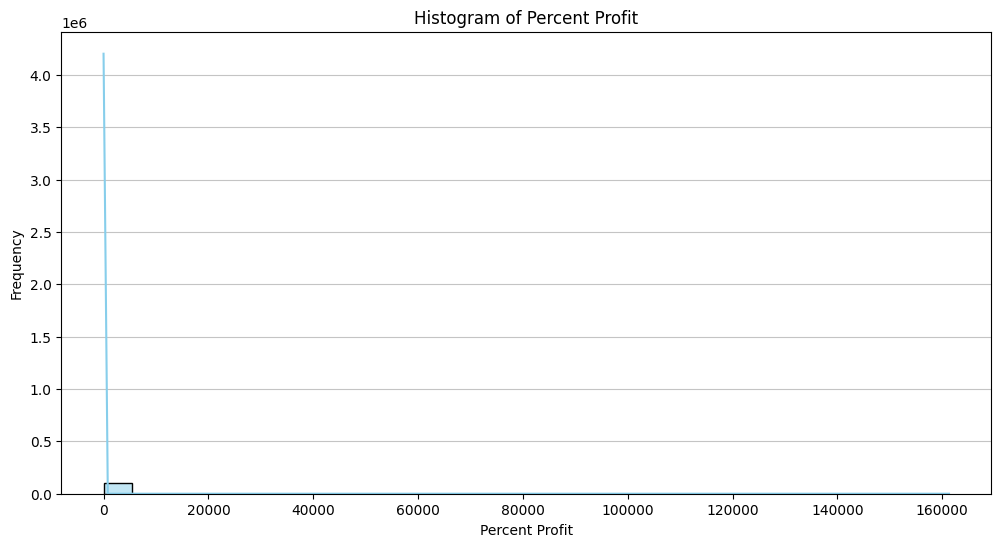

In [30]:
sample = merged_df.sample(n=100000)


plt.figure(figsize=(12, 6))
sns.histplot(sample['PercentProfit'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Histogram of Percent Profit')
plt.xlabel('Percent Profit')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


max_value = sample['PercentProfit'].max()

#### Print basic summary statistics (min, max, mean, median) for 'PercentProfit'.


In [31]:
print(merged_df['PercentProfit'].min())
print(merged_df['PercentProfit'].max())
print(merged_df['PercentProfit'].mean())
print(merged_df['PercentProfit'].median())

-0.9999998672503109
2499999.0
2.437397382471715
-0.7990200780990233


#### Filter outliers in two stages:
1. Remove records with 'PercentProfit' > 5 and <= 0, and plot distribution.
2. Keep records with 'PercentProfit' between 0.17 and 0.37, and plot again.
#### Finally, print the percentage of records remaining after filtering.


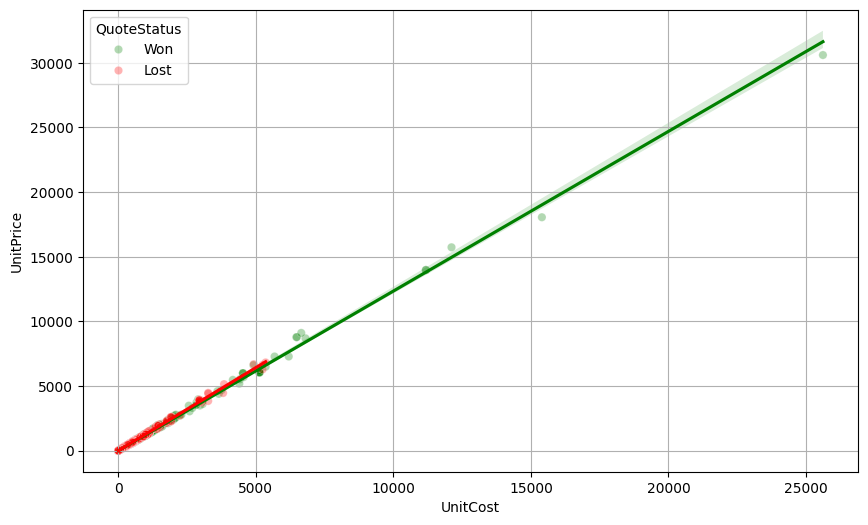

In [33]:
# Define custom colors
custom_colors = {
    'Won': 'green',
    'Lost': 'red'
    
}

# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(data=cleaned, x='UnitCost', y='UnitPrice', alpha=0.3, hue='QuoteStatus', palette=custom_colors)

# Add line of best fit for each status
for status in cleaned['QuoteStatus'].unique():
    subset = cleaned[cleaned['QuoteStatus'] == status]
    sns.regplot(data=subset, x='UnitCost', y='UnitPrice', scatter=False, color=custom_colors[status], line_kws={'label': f'Status {status}'})

# Customize the legend
plt.legend(title='QuoteStatus', loc='upper left')
plt.grid(True)
plt.show()

#### Create a scatter plot of 'UnitCost' vs 'UnitPrice' for the filtered dataset.
#### Color code points by 'QuoteStatus' (Won/Lost) and add a regression line for each group.


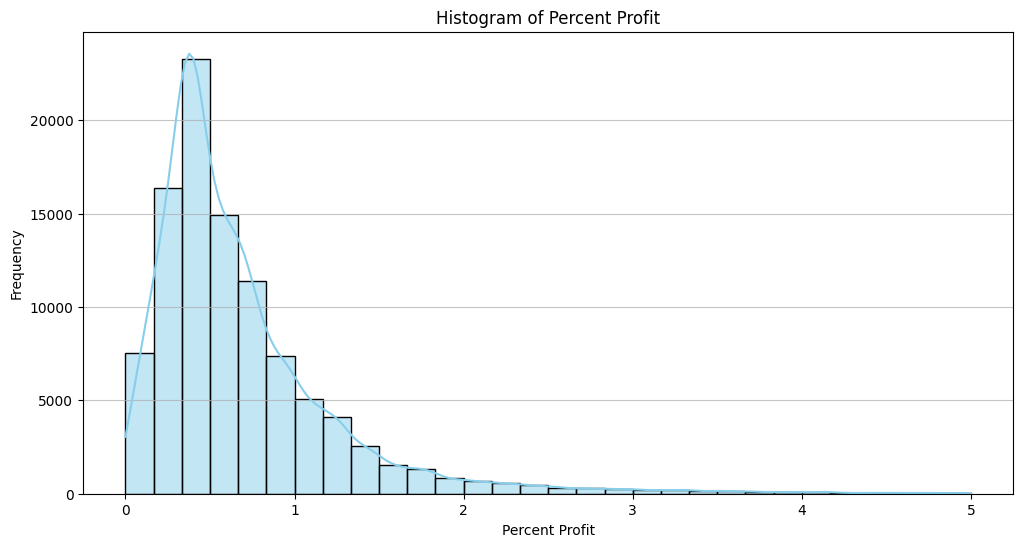

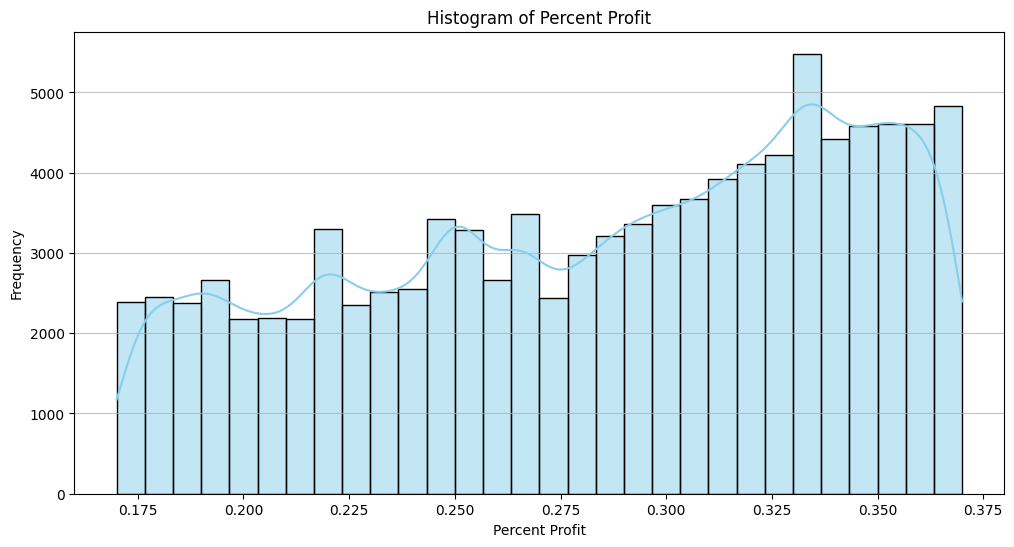

7.8279191264252


In [34]:
cleaned2 = merged_df[merged_df['PercentProfit'] <= 5]
cleaned2 = cleaned2[cleaned2['PercentProfit'] > 0]
sample = cleaned2.sample(n=100000)


plt.figure(figsize=(12, 6))
sns.histplot(sample['PercentProfit'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Histogram of Percent Profit')
plt.xlabel('Percent Profit')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

cleaned = merged_df[merged_df['PercentProfit'] <= .37]
cleaned = cleaned[cleaned['PercentProfit'] > .17]
sample = cleaned.sample(n=100000)


plt.figure(figsize=(12, 6))
sns.histplot(sample['PercentProfit'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Histogram of Percent Profit')
plt.xlabel('Percent Profit')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


cleaned_len=len(cleaned)
original_len=len(merged_df)
print((cleaned_len/original_len)*100)

#### Save the filtered dataset with clean profit margins to 'PercentProfit.csv'.


In [35]:
cleaned.to_csv('./PercentProfit.csv', index=False)

#### Load the 'PercentProfit.csv' file into a DataFrame for further operations.


In [37]:
ProfitPercent=pd.read_csv('PercentProfit.csv')

#### Extract 'CustomerTier', 'PercentProfit', and 'QuoteStatus' columns and save them to 'customer_profit_status.csv' for targeted analysis.


In [38]:
# Select the specific columns you want
selected_data = ProfitPercent[['CustomerTier', 'PercentProfit', 'QuoteStatus']]

# Save to CSV
selected_data.to_csv('customer_profit_status.csv', index=False)